In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv


In [43]:
training_data = pd.read_csv('/kaggle/input/playground-series-s6e1/train.csv', index_col=0)

In [44]:
training_data.head(20)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0
5,24,male,b.com,5.04,85.1,yes,9.4,average,online videos,medium,moderate,70.1
6,20,male,b.sc,4.28,87.0,no,9.1,average,mixed,high,moderate,63.4
7,22,female,ba,4.19,44.9,yes,8.8,good,self-study,high,hard,76.8
8,22,other,b.com,1.06,98.3,yes,5.0,poor,mixed,low,moderate,46.7


In [45]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.5+ MB


In [46]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [47]:
training_data.describe(include='object').T

,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


In [48]:
training_data.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

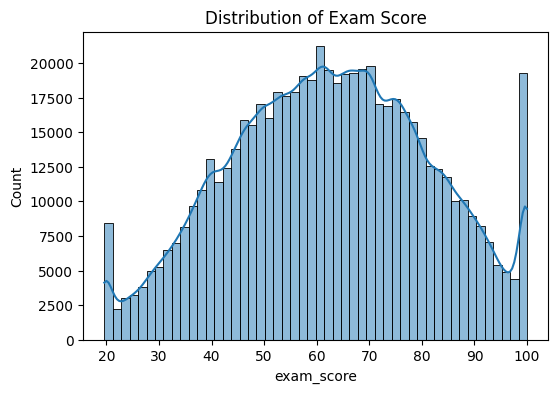

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(training_data['exam_score'], bins=50, kde=True)
plt.title('Distribution of Exam Score')
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'study_hours'}>],
       [<Axes: title={'center': 'class_attendance'}>,
        <Axes: title={'center': 'sleep_hours'}>]], dtype=object)

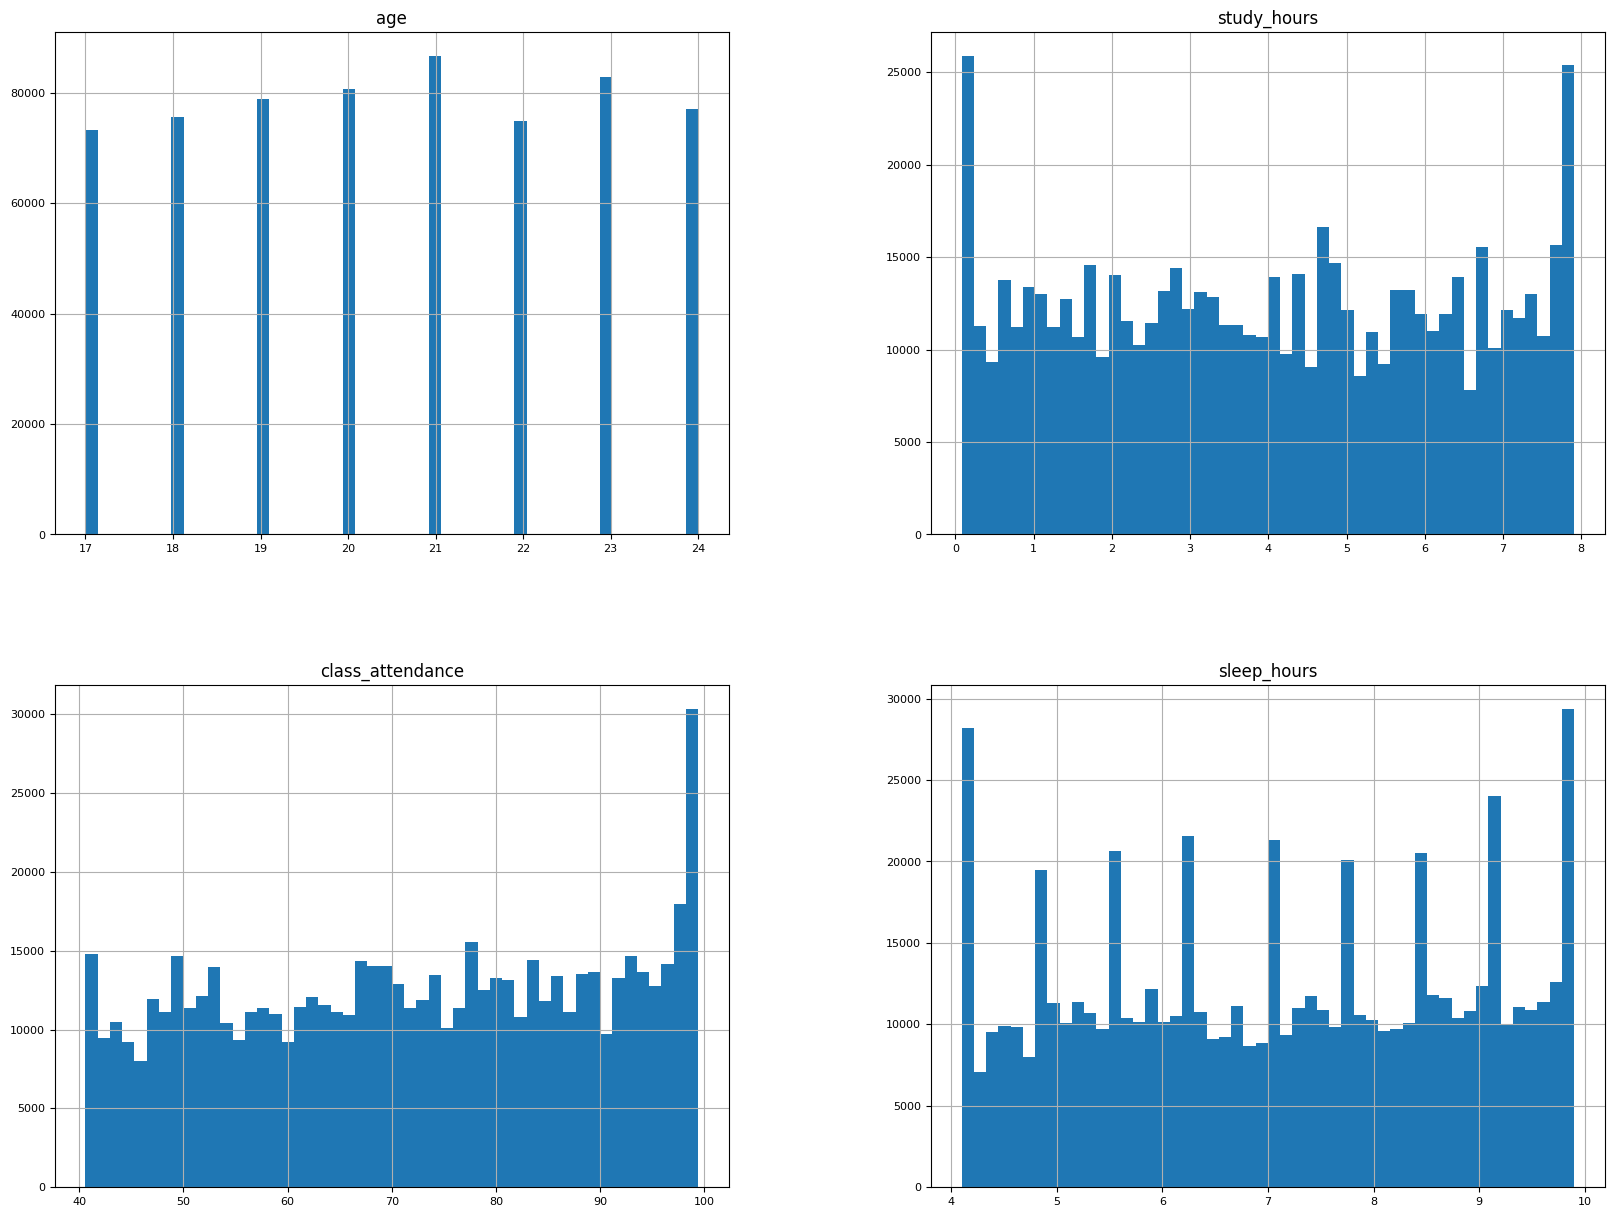

In [50]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
training_data[numerical_cols].hist(figsize=(20, 15), bins=50, xlabelsize=8, ylabelsize=8)

#### Categorical Features Count

In [51]:
categorical_cols = training_data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(training_data[col].value_counts())


gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
internet_access
yes    579423
no      50577
Name: count, dtype: int64
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64


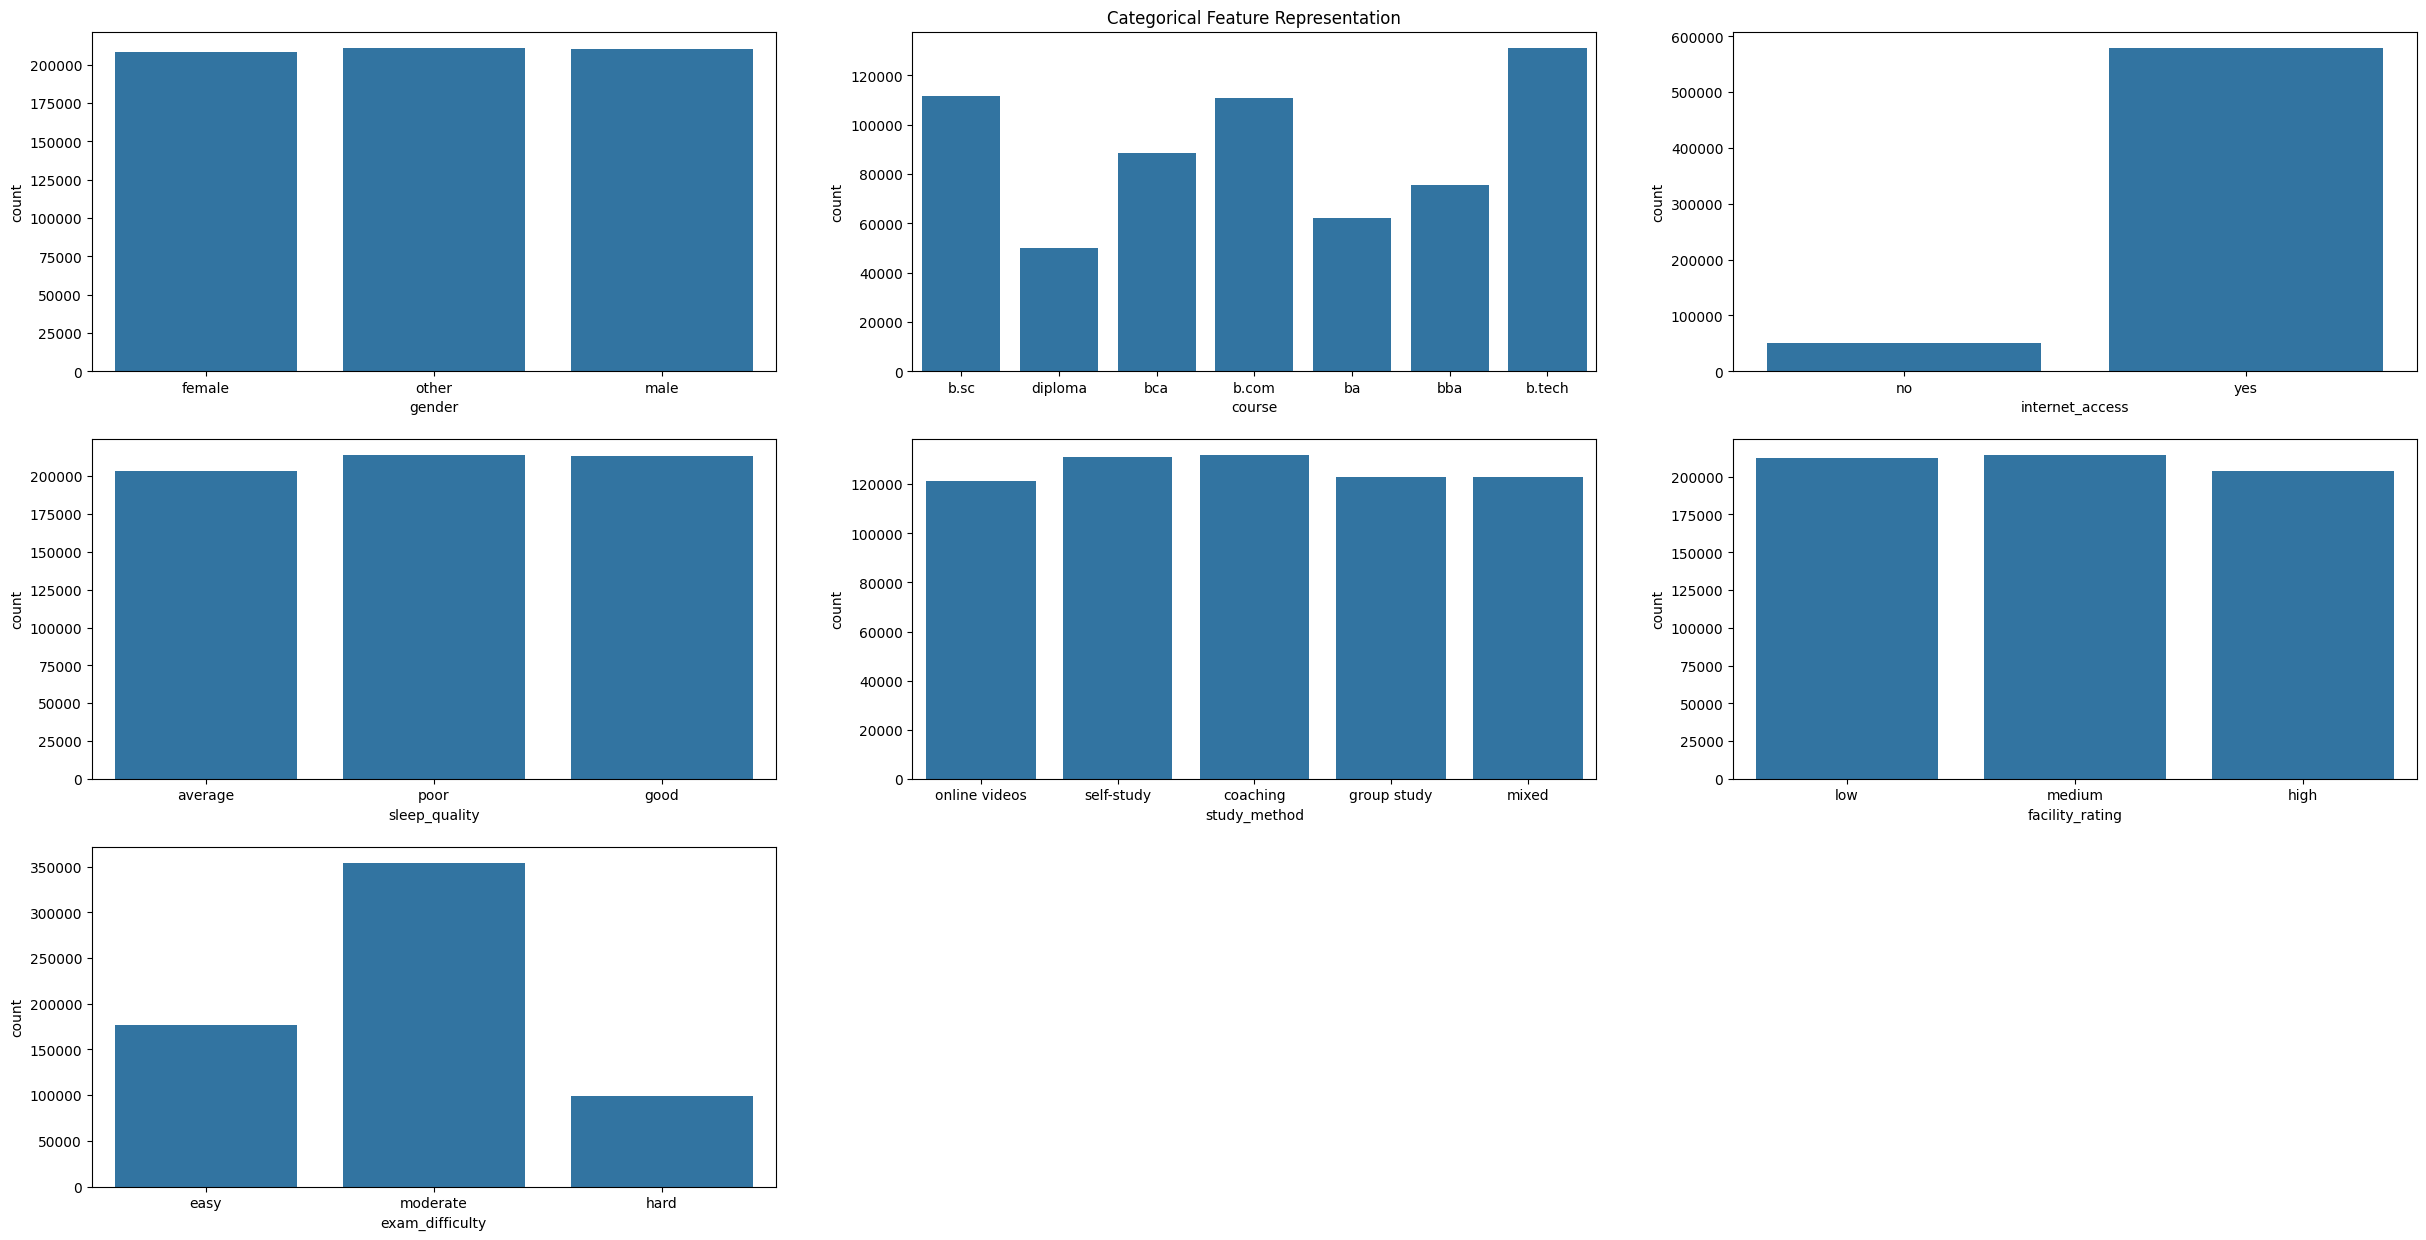

In [52]:
plt.figure(figsize=(30, 15))
plt.title("Categorical Feature Representation")
plot_count = 0
plt.axis("off")

for category in categorical_cols:
    ax = plt.subplot(3, 3, plot_count+1)
    sns.countplot(data=training_data, x=category)
    plot_count += 1

plt.show()

#### Evaluating Correlation matrix with the target variable

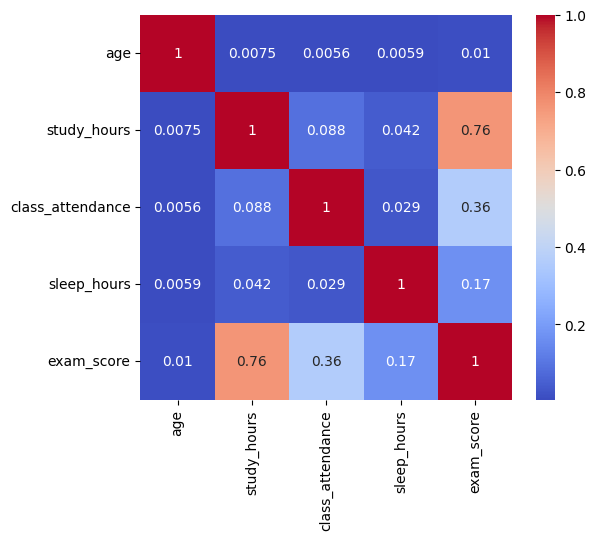

In [53]:
corr = training_data[numerical_cols+['exam_score']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

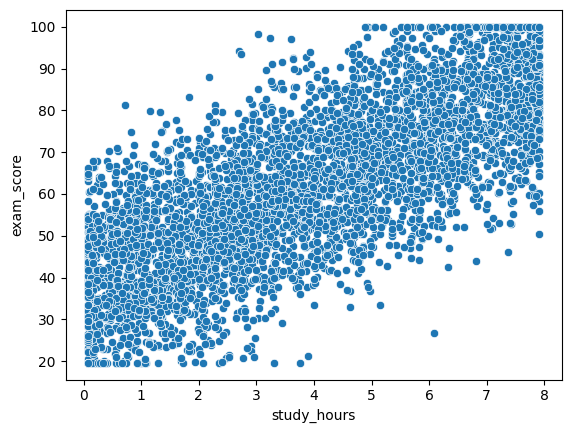

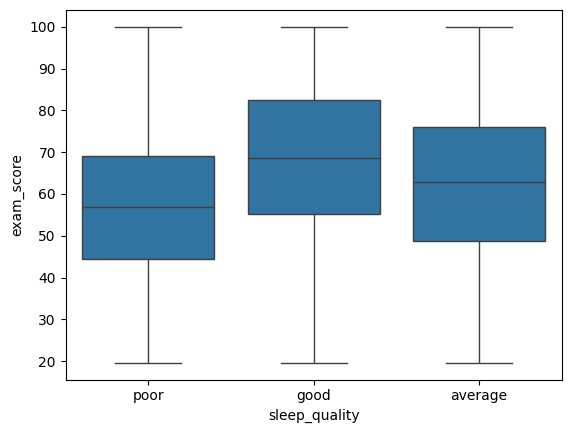

In [54]:
sns.scatterplot(x='study_hours', y='exam_score', data= training_data.sample(5000))
plt.show()

sns.boxplot(x='sleep_quality', y='exam_score', data=training_data.sample(10000))
plt.show()

#### Checking the relationship between categorical features and the target variable

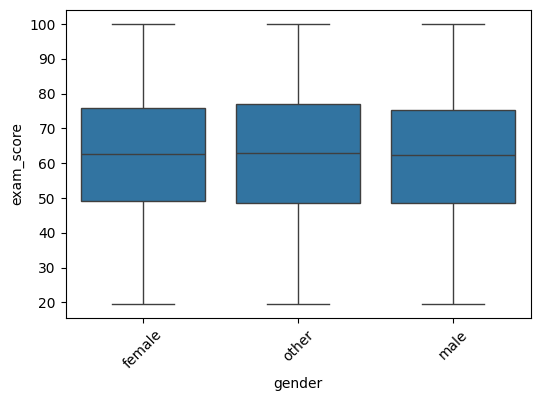

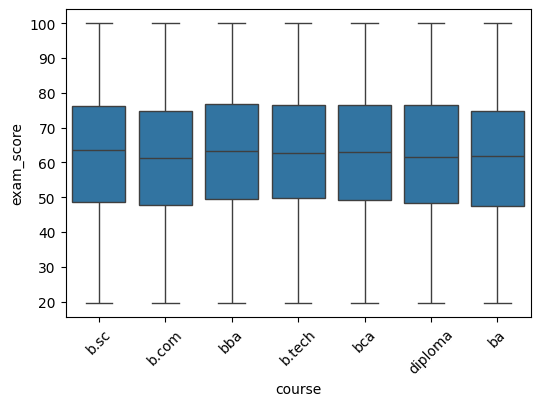

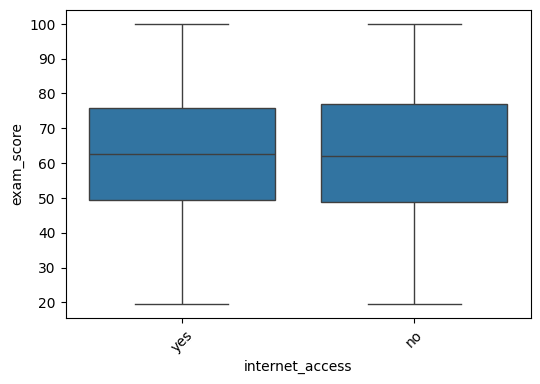

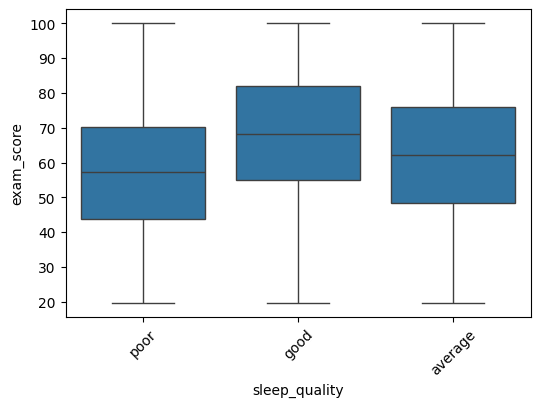

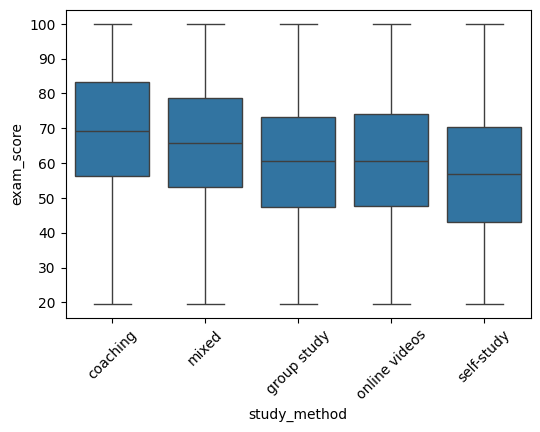

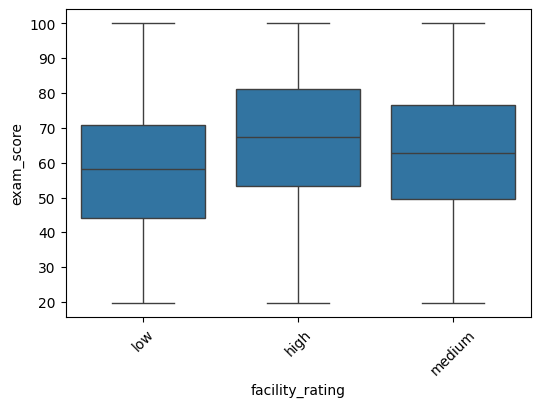

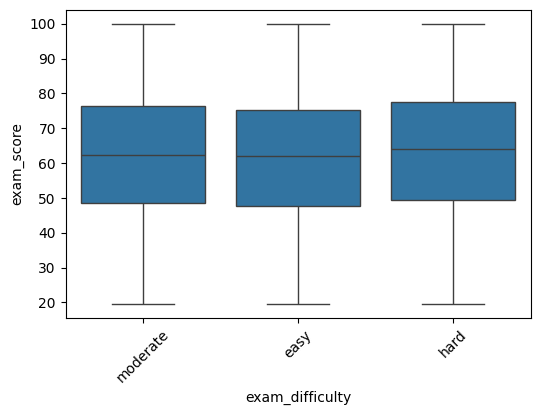

In [55]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y='exam_score', data=training_data.sample(20000))
    plt.xticks(rotation=45)
    plt.show()

#### Feature Processing

In [56]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [57]:
X = training_data.drop('exam_score', axis=1)
y = training_data['exam_score']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

#### Identifing the columns type

In [58]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

#### Preprocessing Pipeline

In [59]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numerical_cols), 
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

#### Baseline Model - Linear Regression 

In [60]:
model = Pipeline([
    ('preprocessor', preprocessor), 
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['age', 'study_hours', 'class_attendance', 'sleep_hours'], dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [61]:
predictions = model.predict(X_valid)

In [62]:
print("MAE: ", mean_absolute_error(y_valid, predictions))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, predictions)))
print("R2: ", r2_score(y_valid, predictions))

MAE:  7.089848185975394
RMSE:  8.878997333212729
R2:  0.7787091014731568


#### Tree Based Model 

In [63]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['age', 'study_hours', 'class_attendance', 'sleep_hours'], dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [64]:
predictions_rfModel = rf_model.predict(X_valid)

In [65]:
print("MAE: ", mean_absolute_error(y_valid, predictions_rfModel))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, predictions_rfModel)))
print("R2: ", r2_score(y_valid, predictions_rfModel))

MAE:  7.213358436014108
RMSE:  9.054810571659056
R2:  0.7698587648731398


#### Gradient Boosting

In [66]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['age', 'study_hours', 'class_attendance', 'sleep_hours'], dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [67]:
predictions_xgbModel = xgb_model.predict(X_valid)

In [68]:
print("MAE: ", mean_absolute_error(y_valid, predictions_xgbModel))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, predictions_xgbModel)))
print("R2: ", r2_score(y_valid, predictions_xgbModel))

MAE:  6.98083237380049
RMSE:  8.750332090582887
R2:  0.7850760705052487


#### Hyperparamter Tuning

In [69]:
param_grid = {
    'regressor__max_depth': [4,6,8,10],
    'regressor__n_estimators': [200,400,600],
    'regressor__learning_rate': [0.01,0.05,0.1]
}

search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END regressor__learning_rate=0.05, regressor__max_depth=6, regressor__n_estimators=200; total time=   6.4s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=6, regressor__n_estimators=200; total time=   6.2s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=6, regressor__n_estimators=200; total time=   6.2s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=6, regressor__n_estimators=200; total time=   6.2s
[CV] END regressor__learning_rate=0.05, regressor__max_depth=6, regressor__n_estimators=200; total time=   6.0s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=10, regressor__n_estimators=600; total time=  24.5s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=10, regressor__n_estimators=600; total time=  24.7s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=10, regressor__n_estimators=600; total time=  32.2s
[CV] END regressor__learning_rate=0.1, regr

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               StandardScaler(),
                                                                               Index(['age', 'study_hours', 'class_attendance', 'sleep_hours'], dtype='object')),
                                                                              ('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating',...
                                                           max_depth=6,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=500,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   param_distributions={'regressor__learning_rate': [0.01, 0.05,
                                                                     0.1],
                                        'regressor__max_depth': [4, 6, 8, 10],
                                        'regressor__n_estimators': [200, 400,
                                                                    600]},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [70]:
best_model = search.best_estimator_

#### Feature Importance

In [71]:
xgb = best_model.named_steps['regressor']
importances = xgb.feature_importances_

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(20)

numeric__study_hours                       0.309778
categorical__study_method_coaching         0.127594
categorical__sleep_quality_poor            0.118066
categorical__sleep_quality_good            0.108683
categorical__facility_rating_low           0.092772
categorical__facility_rating_high          0.060527
numeric__class_attendance                  0.052868
categorical__study_method_mixed            0.034161
categorical__study_method_self-study       0.019010
numeric__sleep_hours                       0.015626
categorical__sleep_quality_average         0.010572
categorical__study_method_online videos    0.009326
categorical__study_method_group study      0.003692
categorical__facility_rating_medium        0.002745
categorical__course_b.sc                   0.002572
categorical__gender_other                  0.002421
categorical__course_b.com                  0.002371
categorical__course_bba                    0.002245
categorical__gender_male                   0.002227
numeric__age

In [72]:
predictions_finalModel = best_model.predict(X_valid)

In [73]:
print("MAE: ", mean_absolute_error(y_valid, predictions_finalModel))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, predictions_finalModel)))
print("R2: ", r2_score(y_valid, predictions_finalModel))

MAE:  6.972226584746064
RMSE:  8.747201671768394
R2:  0.7852298204563705


In [74]:
test_data = pd.read_csv('/kaggle/input/playground-series-s6e1/test.csv', index_col=0)

In [75]:
test_data.head(10)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate
630005,21,male,b.sc,6.22,55.3,yes,4.6,average,mixed,high,moderate
630006,22,other,ba,3.59,91.6,yes,7.7,good,mixed,medium,moderate
630007,20,male,b.sc,3.14,82.7,no,4.2,average,online videos,high,moderate
630008,18,male,diploma,6.49,86.0,yes,7.3,poor,group study,high,easy


In [ ]:
test_pred_linear = model.predict(test_data)

In [77]:
test_pred_rfModel = rf_model.predict(test_data)

In [78]:
test_pred_xgbModel = xgb_model.predict(test_data)

In [79]:
final_predictions = best_model.predict(test_data)

In [80]:
test_predictions = (0.3 * test_pred_linear + 0.7 * final_predictions)

In [81]:
submission= pd.DataFrame({
    'id': test_data.index,
    'exam_score': test_predictions
})

In [82]:
submission.to_csv('submission.csv', index=False)